In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

In [2]:
pima_df = pd.read_csv('pima-indians-diabetes.csv')

In [4]:
pima_df[['Plas', 'Pres', 'skin',
         'test', 'mass', 'pedi', 
         'age']] = pima_df[['Plas', 'Pres', 'skin', 
                            'test', 'mass', 'pedi', 
                            'age']].replace(0, np.nan)
pima_df.head()

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


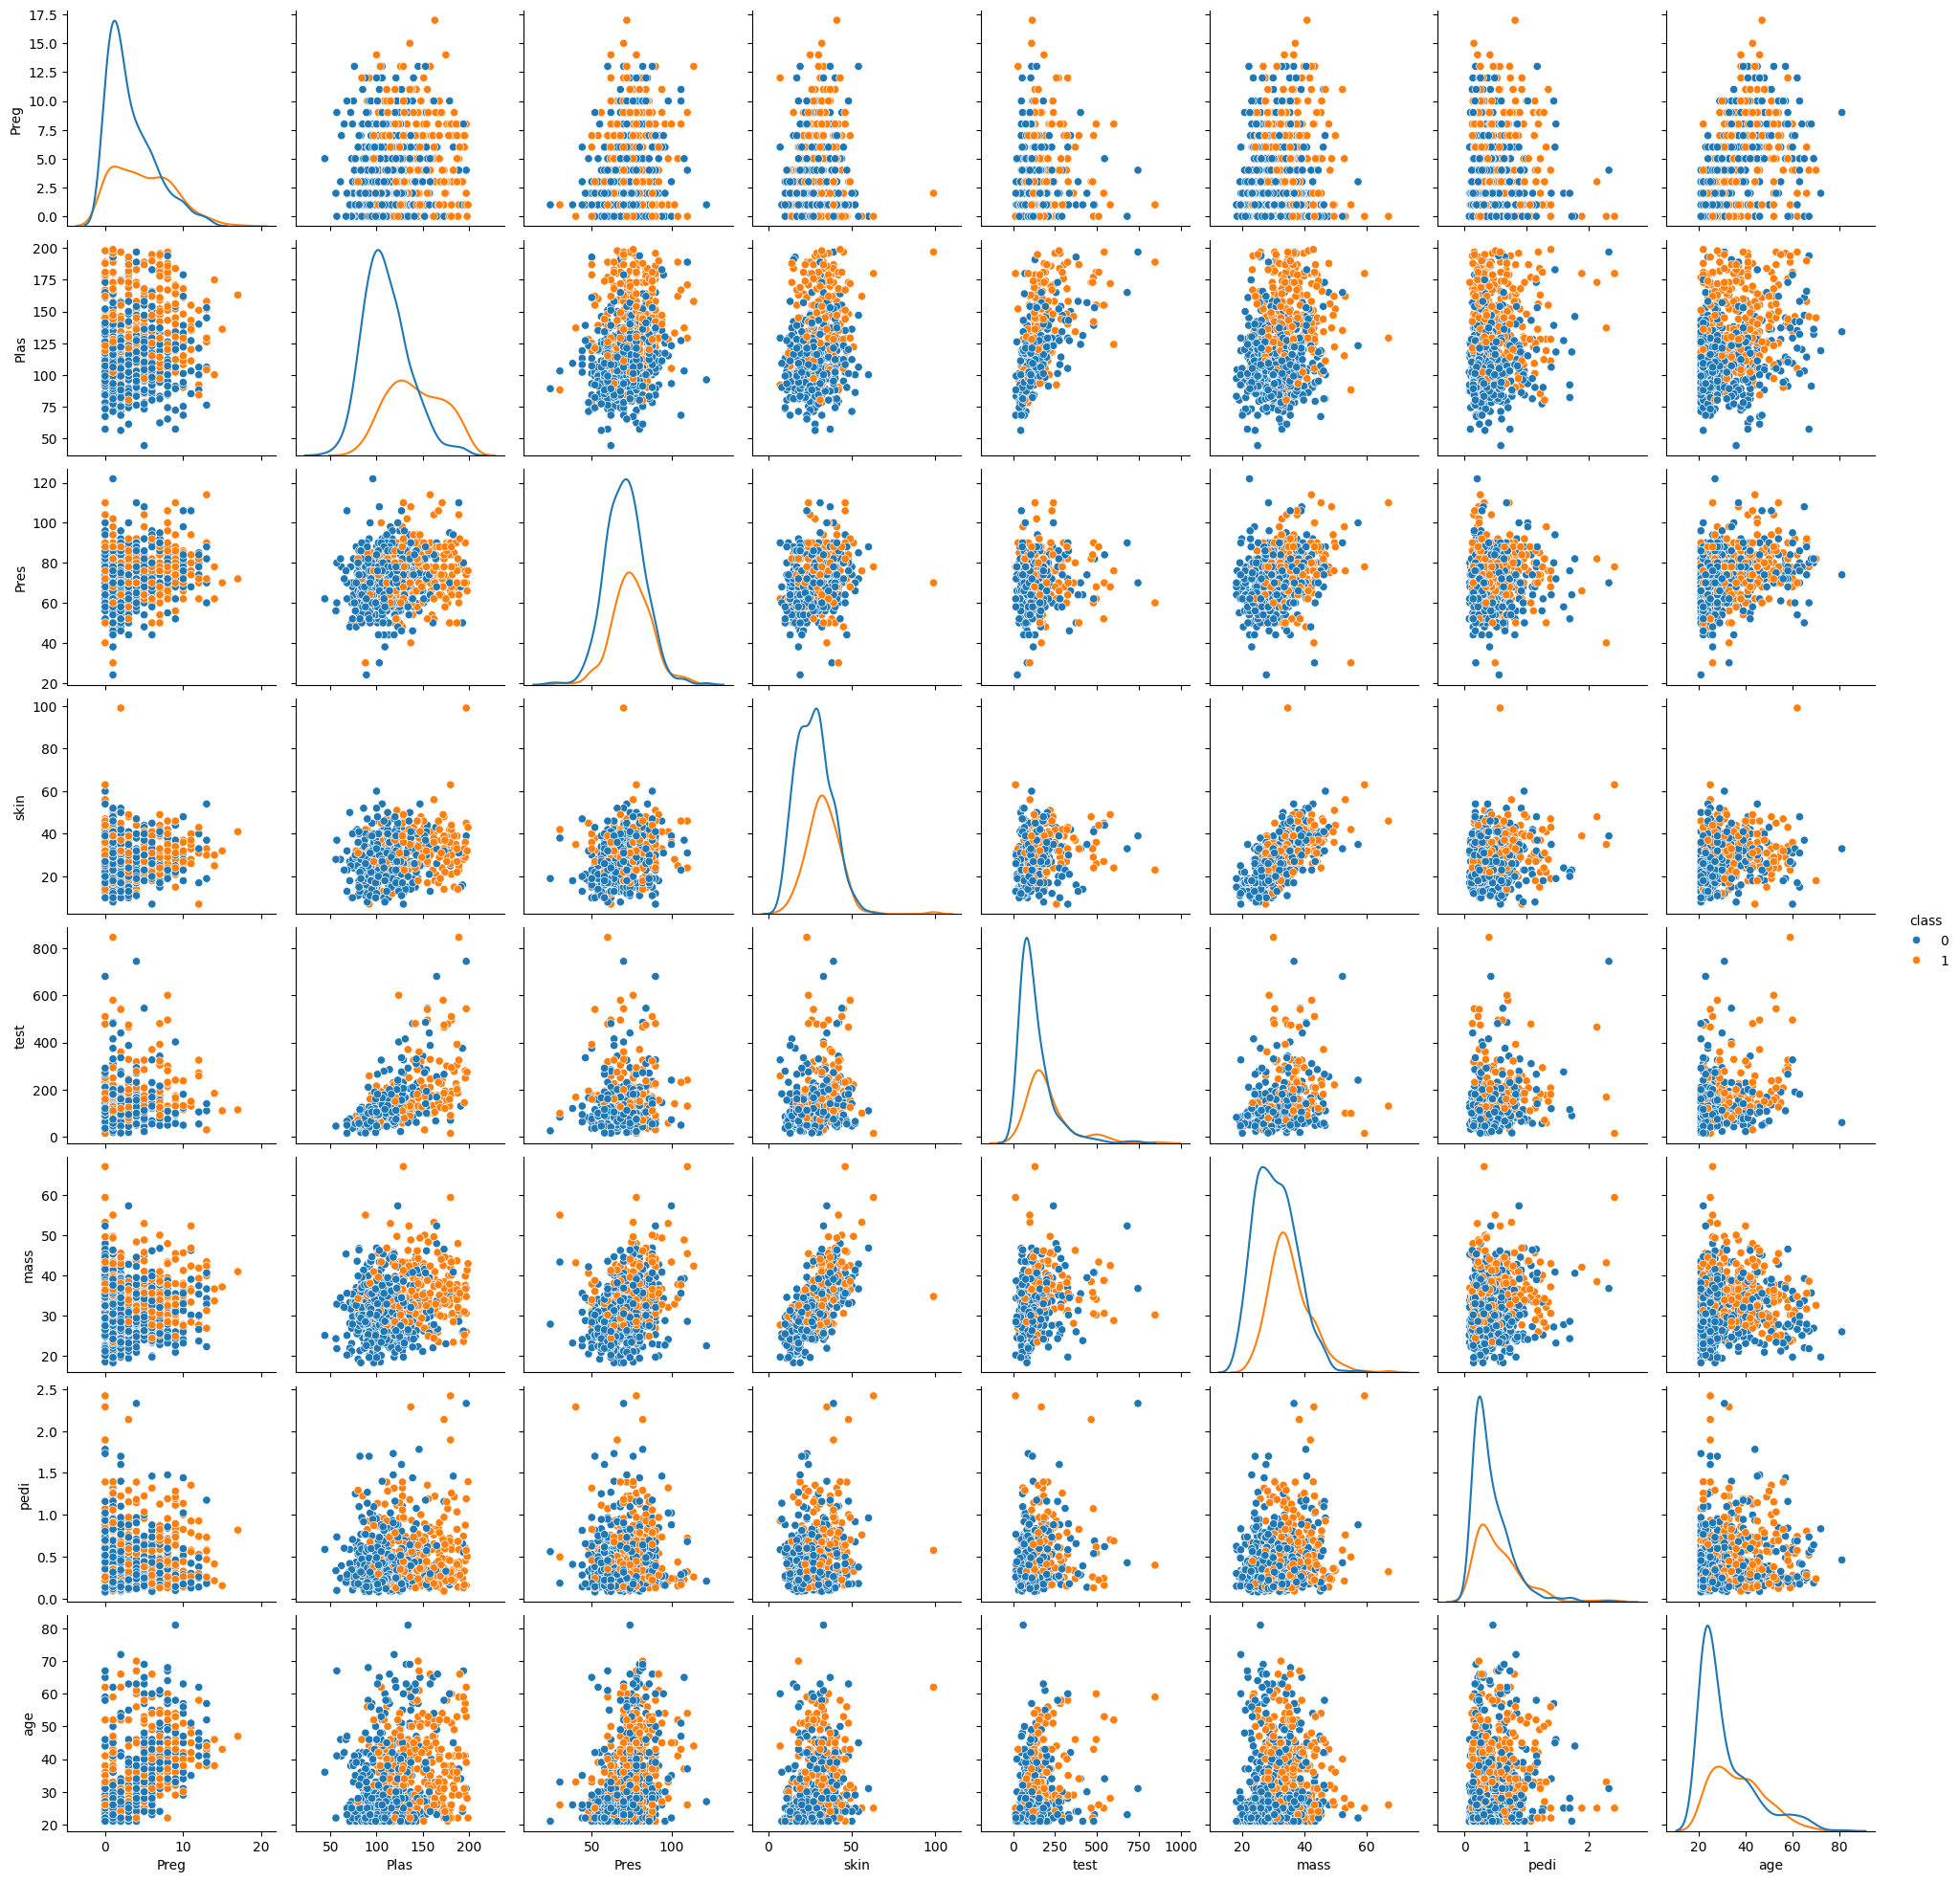

In [7]:
sns.pairplot(pima_df, 
             hue='class',
             diag_kind='kde',
             diag_kws = dict(fill=False))
plt.show()

In [13]:
values = pima_df.values
X = values[:,0:8]
y = values[:,8]

In [11]:
#x2 = pima_df.drop('class', axis=1)

In [14]:
# fill missing values with mean column values
imputer = SimpleImputer(strategy='median', fill_value='numerical')
transformed_X = imputer.fit_transform(X)

In [17]:
(X_train, X_test,
 y_train, y_test) = train_test_split(transformed_X,
                                     y,
                                     test_size=0.3,
                                     random_state=7)

In [29]:
dt_model = DecisionTreeClassifier(criterion='entropy').fit(X_train,
                                                           y_train)

In [30]:
dt_model.score(X_test, y_test)

0.7186147186147186

In [31]:
y_predict = dt_model.predict(X_test)
print(metrics.confusion_matrix(y_test, y_predict))

[[113  34]
 [ 31  53]]


### Regularize the decision tree

In [32]:
dt_model = DecisionTreeClassifier(criterion='entropy',
                                  max_depth=8).fit(X_train, y_train)

In [33]:
dt_model.score(X_test, y_test)

0.7359307359307359

In [34]:
y_predict = dt_model.predict(X_test)
print(metrics.confusion_matrix(y_test, y_predict))

[[111  36]
 [ 25  59]]
